## This notebook contains the experiments which depict why long range connections help in imporving the search 

In the previous experiments, we saw that as K is increased the recall usually goes up! So we are able to reach near quite to the query vector but that requires us to increase the connections per node, which costs computational time and memory as well. 


So, we ask a different question, 'Is it possible to get such a high recall with even lower K' ? That would shoot up the speed of the algorithm, while at the same time reducing the memory requirements

This gives rise to the idea of long range connections, thus making the graph a Navigable Small World Graph [[paper link](https://publications.hse.ru/mirror/pubs/share/folder/x5p6h7thif/direct/128296059)]

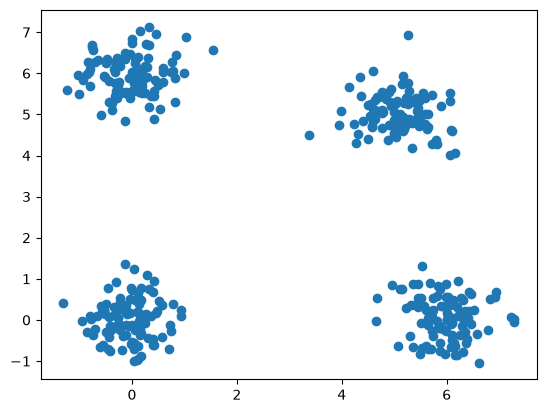

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

np.random.seed(42)

cluster1 = np.random.randn(100, 2) * 0.5 + np.array([0, 0])
cluster2 = np.random.randn(100, 2) * 0.5 + np.array([5, 5])
cluster3 = np.random.randn(100, 2) * 0.5 + np.array([0, 6])
cluster4 = np.random.randn(100, 2) * 0.5 + np.array([6, 0])

X = np.vstack([
    cluster1,
    cluster2,
    cluster3,
    cluster4
])

plt.scatter(X[:, 0], X[:, 1])
plt.show()

### All the useful graph creation functions are given below: 

In [3]:
# ALL OF THE GRAPHs CREATION CODE HERE: 

def euclid(x, y): 
    # x and y both are vectors here
    return np.linalg.norm(x-y)

def get_knn(X, i, k):
    '''
    X : data matrix containing vectors 
    i : the index of the vector whose K nearest neighbours we search 
    k : hyperparameter
    '''
    distances = []

    for j in range(len(X)):
        if i == j:
            continue

        d = euclid(X[i], X[j])
        distances.append((d, j))

    distances.sort()

    return [j for _, j in distances[:k]]

def build_knn_graph(X, k): 
    graph = {}
    
    for i in range(len(X)): 
        graph[i] = get_knn(X, i, k)
    
    return graph 

def exact_search(X, query):
    distances = np.linalg.norm(X - query, axis=1)
    return np.argmin(distances)


##### In the code below, we just create r new connections which are made randomly and some of them will turn out to be quite long range. 

In [4]:
'''
 Each node will keep its original k nearest neighbors and receive r additional randomly chosen connections.
'''

def add_random_shortcuts(graph, n, r, seed=42):
    rng = np.random.default_rng(seed)
    
    new_graph = {i : list(neigh) for i, neigh in graph.items()}
    
    for i in range(n): 
        candidate_points = list(set(range(n)) - {i} - set(new_graph[i]))
        
        if candidate_points: 
            shortcuts = rng.choice(
                candidate_points,
                size = min(r, len(candidate_points)), 
                replace = False 
            )
            new_graph[i].extend(shortcuts.tolist())
        
    return new_graph

The code below does the greedy search while also maintaining the counts of the distance evaluations done. 

In [5]:
def greedy_search_count(X, graph, query, start):
    current = start
    visited = [current] # just stores the path 
    distance_count = 1

    while True:
        best = current
        best_dist = np.linalg.norm(query - X[current]) # just euclidean distance

        for neighbor in graph[current]:
            d = np.linalg.norm(query - X[neighbor])
            distance_count += 1

            if d < best_dist:
                best = neighbor
                best_dist = d

        if best == current:
            break

        current = best
        visited.append(current)

    return current, visited, distance_count

In the code below, we test our new graph on some queries and compare with the old

In [6]:
# Original k-NN graph
base_graph = build_knn_graph(X, k=8)

# Add random shortcuts
shortcut_graph = add_random_shortcuts(
    base_graph,
    n=len(X),
    r=3
)

# Generate test queries
rng = np.random.default_rng(123)
queries = rng.normal(size=(200, 2)) * 3 + 3

def evaluate_graph(X, graph, queries, start=0):
    hits = 0
    total_distances = 0

    for q in queries:
        exact = exact_search(X, q)
        result, path, count = greedy_search_count(
            X, graph, q, start
        )

        hits += (result == exact)
        total_distances += count

    return hits / len(queries), total_distances / len(queries)

print("Original:", evaluate_graph(X, base_graph, queries))
print("Shortcuts:", evaluate_graph(X, shortcut_graph, queries))

Original: (np.float64(0.115), 47.72)
Shortcuts: (np.float64(0.65), 70.19)


Kindly note the amount of improvement we get from these skip connections, from %hit of 47 to a %hit of 70. Recall delta = 54%

#### Below is a plotting function

In [7]:
def plot_search(X, graph, query, path):

    plt.figure(figsize=(10, 10))

    # Graph
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.08
            )

    # All points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        alpha=0.5
    )

    # Query
    plt.scatter(
        query[0],
        query[1],
        marker="*",
        s=250, 
        label = 'query'
    )

    plt.scatter(
        X[path[0]][0],
        X[path[0]][1], 
        marker = '.', 
        s = 350, 
        c = 'r', 
        label='start-point'
    )
    
    # Search path
    for a, b in zip(path[:-1], path[1:]):
        plt.plot(
            [X[a, 0], X[b, 0]],
            [X[a, 1], X[b, 1]],
            linewidth=3,
        )
        
    plt.legend()    
    plt.show() 

In [12]:
query = np.array([4.5, 4.5])

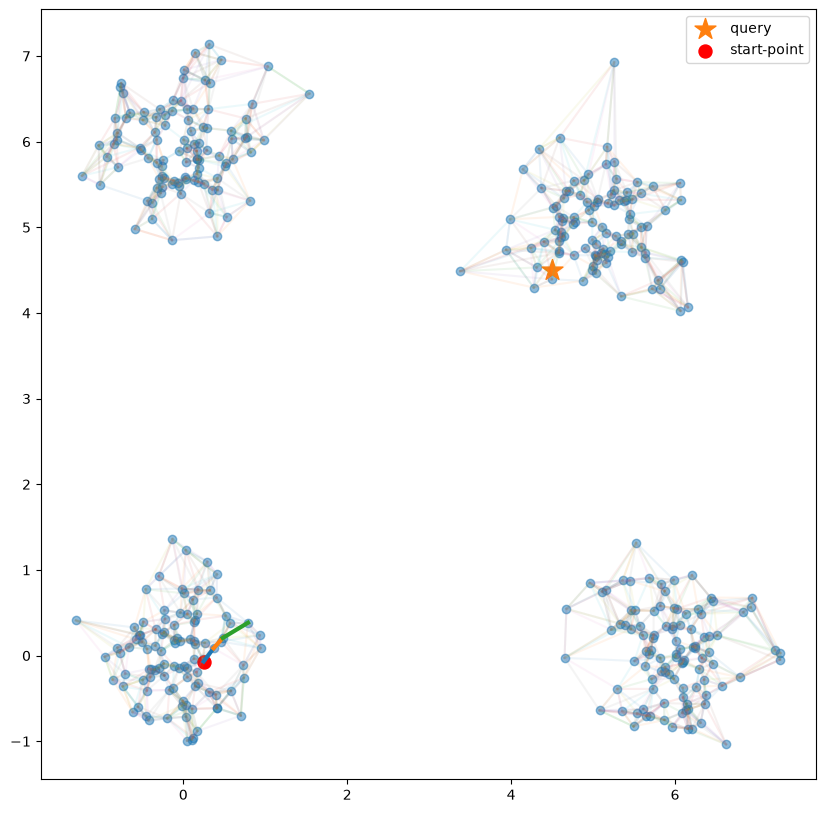

In [13]:
result1, path1, count1 = greedy_search_count(
            X, base_graph, query, start=0
        )

plot_search(X, base_graph, query, path1)

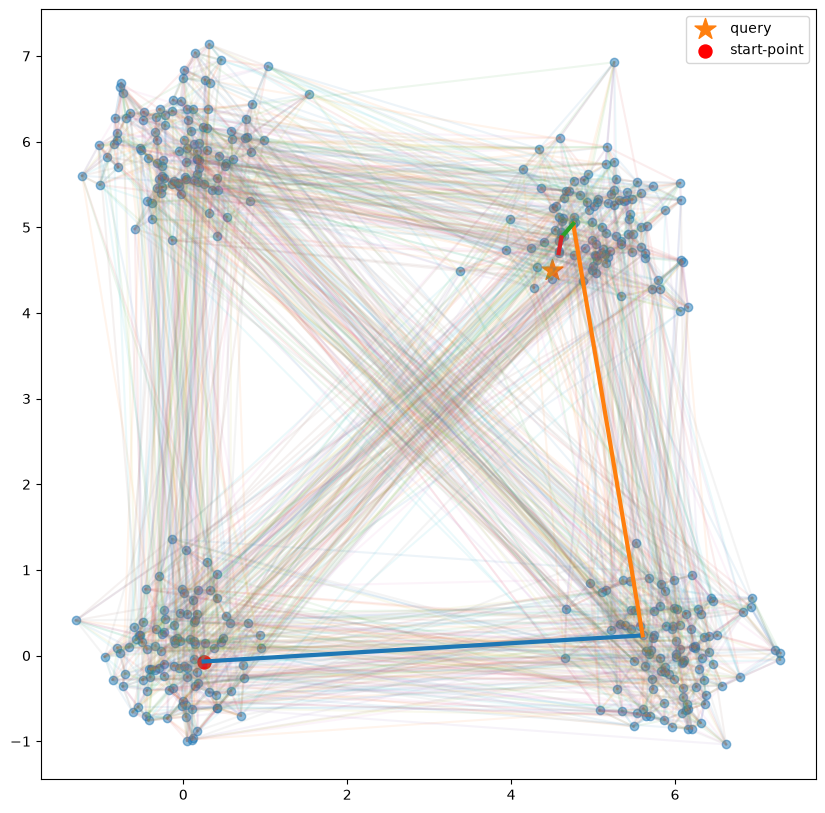

In [14]:
result2, path2, count2 = greedy_search_count(
            X, shortcut_graph, query, start=0
        )

plot_search(X, shortcut_graph, query, path2)

The above plot makes it absolutely clear, Long range connections are extremely useful in obtaining faster convergence to the approximate nearest neighbours. 